In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('/content/predictive_maintenance.csv')
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [30]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


In [31]:
df = df.drop(columns=['UDI', 'Product ID'])
display(df.head())

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


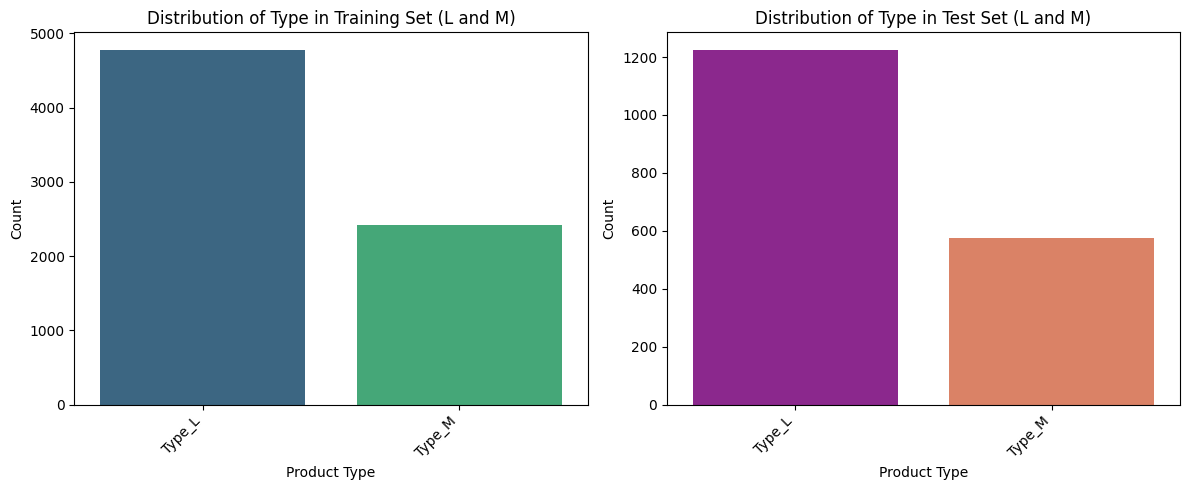

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Type columns from X_train and X_test
# Note: 'Type_H' is not available as a separate column due to drop_first=True during one-hot encoding.
# Its presence is implicitly represented when both Type_L and Type_M are 0.
train_type_counts = X_train[['Type_L', 'Type_M']].sum()
test_type_counts = X_test[['Type_L', 'Type_M']].sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=train_type_counts.index, y=train_type_counts.values, hue=train_type_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Type in Training Set (L and M)')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=test_type_counts.index, y=test_type_counts.values, hue=test_type_counts.index, palette='plasma', legend=False)
plt.title('Distribution of Type in Test Set (L and M)')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [33]:
df = pd.get_dummies(df, columns=['Type', 'Failure Type'], drop_first=True)
display(df.head())

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Type_L,Type_M,Failure Type_No Failure,Failure Type_Overstrain Failure,Failure Type_Power Failure,Failure Type_Random Failures,Failure Type_Tool Wear Failure
0,298.1,308.6,1551,42.8,0,0,False,True,True,False,False,False,False
1,298.2,308.7,1408,46.3,3,0,True,False,True,False,False,False,False
2,298.1,308.5,1498,49.4,5,0,True,False,True,False,False,False,False
3,298.2,308.6,1433,39.5,7,0,True,False,True,False,False,False,False
4,298.2,308.7,1408,40.0,9,0,True,False,True,False,False,False,False


In [34]:
X = df.drop('Target', axis=1)
y = df['Target']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

display(X.head())
display(y.head())

Shape of features (X): (10000, 12)
Shape of target (y): (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M,Failure Type_No Failure,Failure Type_Overstrain Failure,Failure Type_Power Failure,Failure Type_Random Failures,Failure Type_Tool Wear Failure
0,298.1,308.6,1551,42.8,0,False,True,True,False,False,False,False
1,298.2,308.7,1408,46.3,3,True,False,True,False,False,False,False
2,298.1,308.5,1498,49.4,5,True,False,True,False,False,False,False
3,298.2,308.6,1433,39.5,7,True,False,True,False,False,False,False
4,298.2,308.7,1408,40.0,9,True,False,True,False,False,False,False


,Target
0,0
1,0
2,0
3,0
4,0


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 12)
Shape of X_test: (2000, 12)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled X_train:", X_train_scaled.shape)
print("Shape of scaled X_test:", X_test_scaled.shape)

print("First 5 rows of scaled X_train:\n", X_train_scaled[:5])
print("First 5 rows of scaled X_test:\n", X_test_scaled[:5])

Shape of scaled X_train: (8000, 12)
Shape of scaled X_test: (2000, 12)
First 5 rows of scaled X_train:
 [[0.32608696 0.41975309 0.25513196 0.37707182 0.77075099 1.
  0.         1.         0.         0.         0.         0.        ]
 [0.31521739 0.33333333 0.12140762 0.69060773 0.54150198 1.
  0.         1.         0.         0.         0.         0.        ]
 [0.31521739 0.25925926 0.20351906 0.37707182 0.76679842 1.
  0.         1.         0.         0.         0.         0.        ]
 [0.60869565 0.62962963 0.24516129 0.40331492 0.02766798 0.
  1.         1.         0.         0.         0.         0.        ]
 [0.66304348 0.59259259 0.228739   0.41574586 0.82213439 1.
  0.         1.         0.         0.         0.         0.        ]]
First 5 rows of scaled X_test:
 [[0.59782609 0.56790123 0.20938416 0.4461326  0.7826087  1.
  0.         1.         0.         0.         0.         0.        ]
 [0.90217391 0.75308642 0.14076246 0.56629834 0.39920949 0.
  1.         1.         0.   

### Target Variable Distribution

Let's visualize the distribution of the `Target` variable (failure vs. no failure) in both the training and test datasets to ensure a balanced split.

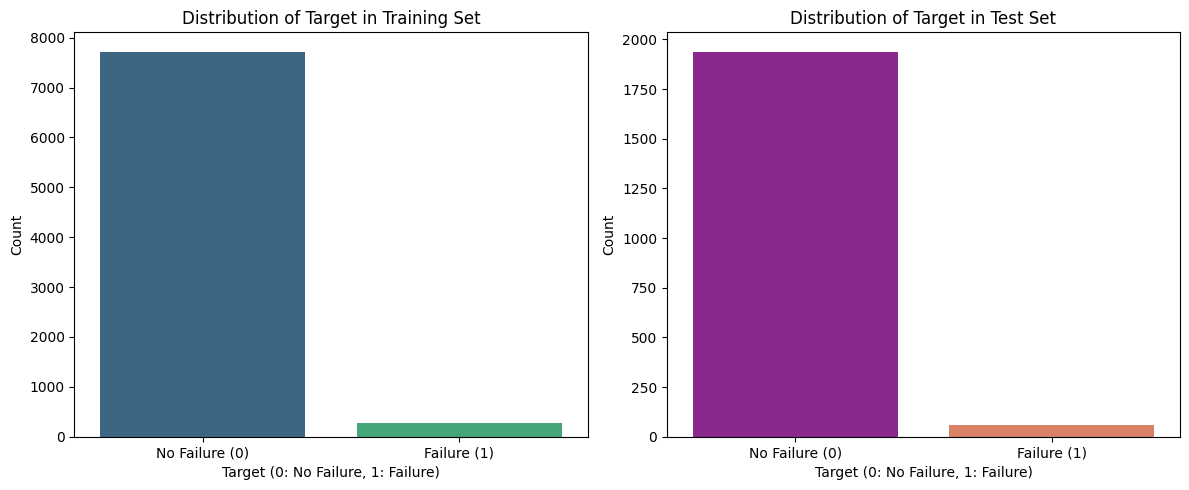

In [37]:
# Get counts for training target
train_target_counts = y_train.value_counts().sort_index()

# Get counts for test target
test_target_counts = y_test.value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=train_target_counts.index, y=train_target_counts.values, hue=train_target_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Target in Training Set')
plt.xlabel('Target (0: No Failure, 1: Failure)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Failure (0)', 'Failure (1)'])

plt.subplot(1, 2, 2)
sns.barplot(x=test_target_counts.index, y=test_target_counts.values, hue=test_target_counts.index, palette='plasma', legend=False)
plt.title('Distribution of Target in Test Set')
plt.xlabel('Target (0: No Failure, 1: Failure)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Failure (0)', 'Failure (1)'])

plt.tight_layout()
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Train the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [39]:
# Make predictions on the scaled test data
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

print("First 10 predictions:", y_pred_log_reg[:10])
print("First 10 true labels:", y_test.head(10).values)

First 10 predictions: [0 0 0 0 0 1 0 0 0 0]
First 10 true labels: [0 1 0 0 0 1 0 0 0 0]


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)
f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:")
print(conf_matrix)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9672
F1-Score: 0.9833

Confusion Matrix:
[[1939    0]
 [   2   59]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [41]:
y_pred_log_reg_train = log_reg_model.predict(X_train_scaled)

conf_matrix_train = confusion_matrix(y_train, y_pred_log_reg_train)
print("\nConfusion Matrix (Training Set):")
print(conf_matrix_train)

conf_matrix_test = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix (Test Set):")
print(conf_matrix_test)


Confusion Matrix (Training Set):
[[7722    0]
 [   7  271]]

Confusion Matrix (Test Set):
[[1939    0]
 [   2   59]]


It's often helpful to visualize the confusion matrices as heatmaps for better understanding.

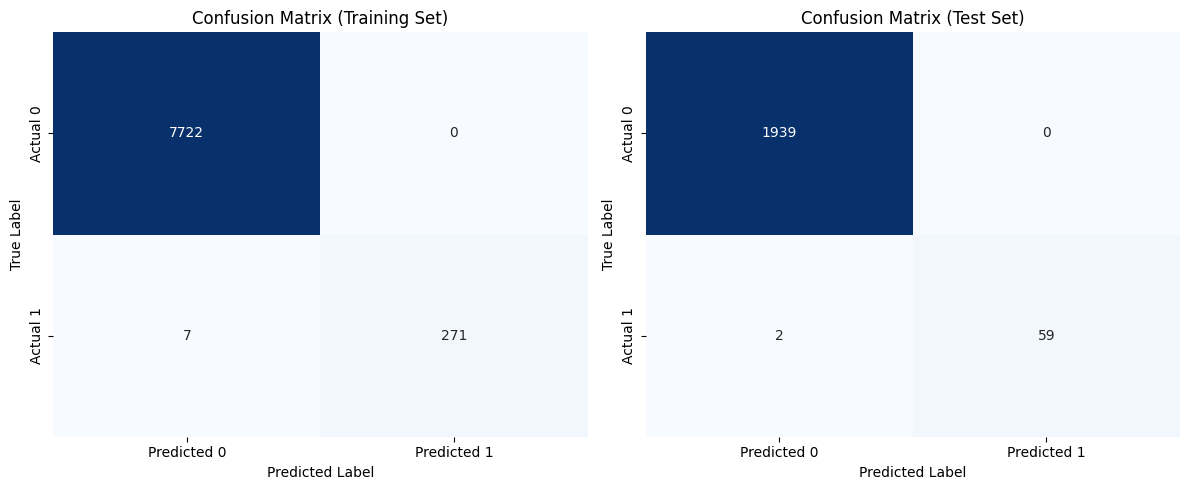

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Clarification on 'Type_H' Column

The `Type_H` column is not explicitly present in the DataFrame after one-hot encoding because `pd.get_dummies` was used with `drop_first=True`. This parameter drops one of the categories (in this case, likely 'H') to prevent multicollinearity, a common issue in statistical models. The information for 'Type_H' is implicitly captured when both `Type_L` and `Type_M` are 0. Therefore, we can only visualize the distributions for `Type_L` and `Type_M`.

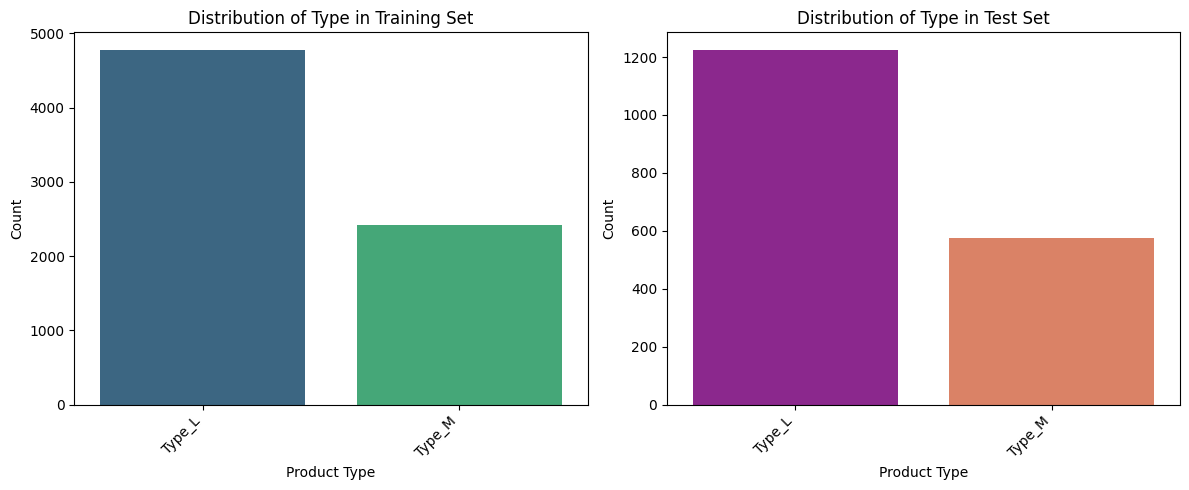

In [43]:
# Extract Type columns from X_train and X_test
train_type_counts = X_train[['Type_L', 'Type_M']].sum()
test_type_counts = X_test[['Type_L', 'Type_M']].sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=train_type_counts.index, y=train_type_counts.values, hue=train_type_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Type in Training Set')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=test_type_counts.index, y=test_type_counts.values, hue=test_type_counts.index, palette='plasma', legend=False)
plt.title('Distribution of Type in Test Set')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import classification_report

print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_pred_log_reg_train))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_log_reg))


Classification Report (Training Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7722
           1       1.00      0.97      0.99       278

    accuracy                           1.00      8000
   macro avg       1.00      0.99      0.99      8000
weighted avg       1.00      1.00      1.00      8000


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



### Type Variable Distribution

Let's visualize the distribution of the `Type` variable in both the training and test datasets to see if the proportions are similar.